# Backbone Eval: ELSA + WWW TopKSAE-8192

This notebook runs practical offline checks for the SAE steering backbone:

- ID mapping sanity between model cache and MovieLens variants
- recommendation pool bias diagnostics (age/popularity/genres)
- lightweight holdout ranking evaluation (Recall/NDCG@K)


In [4]:
from pathlib import Path
import sys
import math
import random
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def resolve_repo_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "server").exists() and (candidate / "server" / "app.py").exists():
            return candidate
    raise RuntimeError("Could not resolve EasyStudy repo root from current working directory")


ROOT = resolve_repo_root(Path.cwd())
print(f"Using ROOT={ROOT}")

sys.path.insert(0, str(ROOT / "server"))
sys.path.insert(0, str(ROOT / "server" / "plugins" / "sae_steering"))

from plugins.utils.data_loading import load_ml_dataset
from plugins.sae_steering.sae_recommender import get_sae_recommender

MODEL_ID = "www_TopKSAE_8192"
DATASETS = ["ml-latest"]
TOP_K = 20
N_USERS_EVAL = 200
SEED = 42
random.seed(SEED)
np.random.seed(SEED)


Using ROOT=/Users/vaclav.stibor/Library/CloudStorage/OneDrive-HomeCreditInternationala.s/Documents/EasyStudy


In [5]:
rec = get_sae_recommender(model_id=MODEL_ID)
rec.load()
model_item_ids = {int(mid) for mid in rec.item_ids}
print(f"Loaded model: {MODEL_ID} with {len(model_item_ids)} item IDs")

id_rows = []
loaders = {}
for dataset in DATASETS:
    loader = load_ml_dataset(ml_variant=dataset)
    loaders[dataset] = loader
    dataset_ids = {int(mid) for mid in loader.movies_df_indexed.index.tolist()}
    overlap = model_item_ids & dataset_ids
    id_rows.append({
        "dataset": dataset,
        "model_items": len(model_item_ids),
        "dataset_items": len(dataset_ids),
        "overlap": len(overlap),
        "model_coverage_in_dataset": len(overlap) / max(len(model_item_ids), 1),
        "dataset_coverage_in_model": len(overlap) / max(len(dataset_ids), 1),
    })

id_df = pd.DataFrame(id_rows).sort_values("dataset")
id_df


Loaded model: www_TopKSAE_8192 with 54999 item IDs


,dataset,model_items,dataset_items,overlap,model_coverage_in_dataset,dataset_coverage_in_model
0,ml-latest,54999,1930,1930,0.035092,1.0


In [7]:
rec_samples_by_dataset = {}


def recommend_for_seed(seed_movie_ids, allowed_ids, n_items=TOP_K):
    id2idx = {int(mid): i for i, mid in enumerate(rec.item_ids)}
    acts = []
    for mid in seed_movie_ids:
        idx = id2idx.get(int(mid))
        if idx is not None:
            a = rec.item_features[idx]
            if hasattr(a, "cpu"):
                a = a.cpu().numpy()
            acts.append(a)
    if acts:
        mean_act = np.mean(acts, axis=0)
        seed_adjustments = {int(i): float(v) for i, v in enumerate(mean_act) if float(v) > 0.0}
    else:
        seed_adjustments = {}

    results = rec.get_recommendations(
        feature_adjustments=seed_adjustments,
        n_items=max(n_items * 10, 200),
        exclude_items=[int(x) for x in seed_movie_ids],
        allowed_ids=set(int(x) for x in allowed_ids),
        seed_adjustments=seed_adjustments,
    )
    return [r["movie_id"] for r in results[:n_items]]


def popularity_and_age_profile(loader, movie_ids):
    movies = loader.movies_df_indexed
    ratings = loader.ratings_df
    counts = ratings["movieId"].value_counts().to_dict()
    years = []
    pops = []
    genres = Counter()
    for mid in movie_ids:
        if mid not in movies.index:
            continue
        row = movies.loc[mid]
        y = row.get("year")
        if pd.notna(y):
            years.append(int(y))
        pops.append(int(counts.get(mid, 0)))
        gs = str(row.get("genres", ""))
        for g in gs.split("|"):
            g = g.strip()
            if g and g != "(no genres listed)":
                genres[g] += 1
    return {
        "n": len(movie_ids),
        "avg_year": float(np.mean(years)) if years else float("nan"),
        "median_year": float(np.median(years)) if years else float("nan"),
        "avg_popularity": float(np.mean(pops)) if pops else float("nan"),
        "median_popularity": float(np.median(pops)) if pops else float("nan"),
        "top_genres": genres.most_common(8),
    }


In [8]:
bias_rows = []
for dataset in DATASETS:
    loader = loaders[dataset]
    ratings = loader.ratings_df.sort_values(["userId", "timestamp"])
    user_groups = ratings.groupby("userId")
    user_ids = [uid for uid, grp in user_groups if len(grp) >= 8]
    sample_users = random.sample(user_ids, min(60, len(user_ids)))

    all_recommended = []
    for uid in sample_users:
        grp = user_groups.get_group(uid)
        seeds = grp["movieId"].head(5).tolist()
        rec_ids = recommend_for_seed(seeds, loader.movies_df_indexed.index.tolist(), n_items=TOP_K)
        all_recommended.extend(rec_ids)

    rec_samples_by_dataset[dataset] = all_recommended[:]
    rec_profile = popularity_and_age_profile(loader, all_recommended)
    catalog_profile = popularity_and_age_profile(loader, loader.movies_df_indexed.index.tolist())
    bias_rows.append({
        "dataset": dataset,
        "rec_avg_year": rec_profile["avg_year"],
        "catalog_avg_year": catalog_profile["avg_year"],
        "rec_avg_popularity": rec_profile["avg_popularity"],
        "catalog_avg_popularity": catalog_profile["avg_popularity"],
        "rec_top_genres": rec_profile["top_genres"],
    })

bias_df = pd.DataFrame(bias_rows)
bias_df


[SAERecommender.get_recommendations] WARNING: restrictive allowed_id mask (1930/54999 items allowed)
[SAERecommender.get_recommendations] WARNING: restrictive allowed_id mask (1930/54999 items allowed)
[SAERecommender.get_recommendations] WARNING: restrictive allowed_id mask (1930/54999 items allowed)
[SAERecommender.get_recommendations] WARNING: restrictive allowed_id mask (1930/54999 items allowed)
[SAERecommender.get_recommendations] WARNING: restrictive allowed_id mask (1930/54999 items allowed)
[SAERecommender.get_recommendations] WARNING: restrictive allowed_id mask (1930/54999 items allowed)
[SAERecommender.get_recommendations] WARNING: restrictive allowed_id mask (1930/54999 items allowed)
[SAERecommender.get_recommendations] WARNING: restrictive allowed_id mask (1930/54999 items allowed)
[SAERecommender.get_recommendations] WARNING: restrictive allowed_id mask (1930/54999 items allowed)
[SAERecommender.get_recommendations] WARNING: restrictive allowed_id mask (1930/54999 items

,dataset,rec_avg_year,catalog_avg_year,rec_avg_popularity,catalog_avg_popularity,rec_top_genres
0,ml-latest,2002.258333,2011.302591,6512.159167,1403.715544,"[(Drama, 662), (Thriller, 480), (Action, 455),..."


In [9]:
def ndcg_at_k(recommended, relevant_set, k=20):
    dcg = 0.0
    for rank, mid in enumerate(recommended[:k], start=1):
        if mid in relevant_set:
            dcg += 1.0 / math.log2(rank + 1)
    ideal_hits = min(len(relevant_set), k)
    if ideal_hits == 0:
        return 0.0
    idcg = sum(1.0 / math.log2(rank + 1) for rank in range(1, ideal_hits + 1))
    return dcg / idcg


def evaluate_holdout(loader, n_users=N_USERS_EVAL, seed_size=5, k=TOP_K):
    ratings = loader.ratings_df.sort_values(["userId", "timestamp"])
    user_groups = ratings.groupby("userId")
    user_ids = [uid for uid, grp in user_groups if len(grp) >= (seed_size + 3)]
    sample_users = random.sample(user_ids, min(n_users, len(user_ids)))
    allowed = set(int(x) for x in loader.movies_df_indexed.index.tolist())

    recalls = []
    ndcgs = []
    for uid in sample_users:
        grp = user_groups.get_group(uid)
        positive = grp[grp["rating"] >= 4.0]["movieId"].tolist()
        if len(positive) < (seed_size + 1):
            continue

        seed = positive[:seed_size]
        holdout = set(int(x) for x in positive[seed_size:])
        rec_ids = recommend_for_seed(seed, allowed_ids=allowed, n_items=k)

        hits = sum(1 for x in rec_ids if x in holdout)
        recalls.append(hits / max(min(len(holdout), k), 1))
        ndcgs.append(ndcg_at_k(rec_ids, holdout, k=k))

    return {
        "users_evaluated": len(recalls),
        f"Recall@{k}": float(np.mean(recalls)) if recalls else 0.0,
        f"NDCG@{k}": float(np.mean(ndcgs)) if ndcgs else 0.0,
    }


metrics = []
for dataset in DATASETS:
    metrics.append({"dataset": dataset, **evaluate_holdout(loaders[dataset])})

metrics_df = pd.DataFrame(metrics)
metrics_df


[SAERecommender.get_recommendations] WARNING: restrictive allowed_id mask (1930/54999 items allowed)
[SAERecommender.get_recommendations] WARNING: restrictive allowed_id mask (1930/54999 items allowed)
[SAERecommender.get_recommendations] WARNING: restrictive allowed_id mask (1930/54999 items allowed)
[SAERecommender.get_recommendations] WARNING: restrictive allowed_id mask (1930/54999 items allowed)
[SAERecommender.get_recommendations] WARNING: restrictive allowed_id mask (1930/54999 items allowed)
[SAERecommender.get_recommendations] WARNING: restrictive allowed_id mask (1930/54999 items allowed)
[SAERecommender.get_recommendations] WARNING: restrictive allowed_id mask (1930/54999 items allowed)
[SAERecommender.get_recommendations] WARNING: restrictive allowed_id mask (1930/54999 items allowed)
[SAERecommender.get_recommendations] WARNING: restrictive allowed_id mask (1930/54999 items allowed)
[SAERecommender.get_recommendations] WARNING: restrictive allowed_id mask (1930/54999 items

,dataset,users_evaluated,Recall@20,NDCG@20
0,ml-latest,200,0.501,0.523556


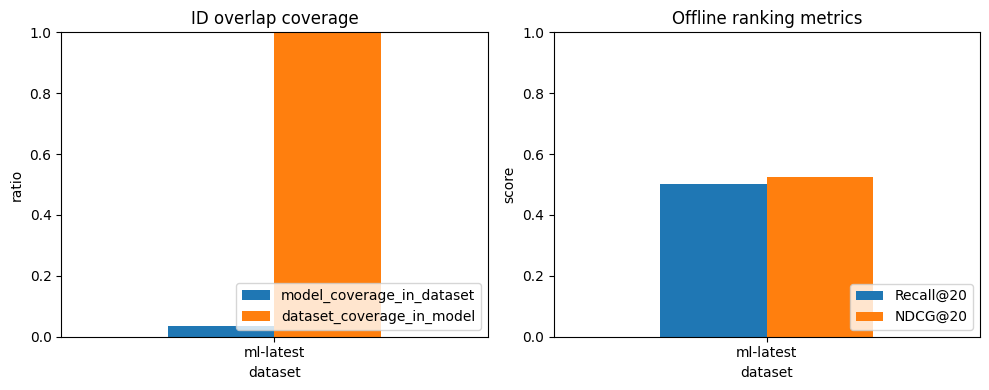

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

id_plot = id_df[["dataset", "model_coverage_in_dataset", "dataset_coverage_in_model"]].set_index("dataset")
id_plot.plot(kind="bar", ax=axes[0], ylim=(0, 1), rot=0)
axes[0].set_title("ID overlap coverage")
axes[0].set_ylabel("ratio")
axes[0].legend(loc="lower right")

metrics_plot = metrics_df.set_index("dataset")[[f"Recall@{TOP_K}", f"NDCG@{TOP_K}"]]
metrics_plot.plot(kind="bar", ax=axes[1], ylim=(0, 1), rot=0)
axes[1].set_title("Offline ranking metrics")
axes[1].set_ylabel("score")
axes[1].legend(loc="lower right")

plt.tight_layout()
plt.show()


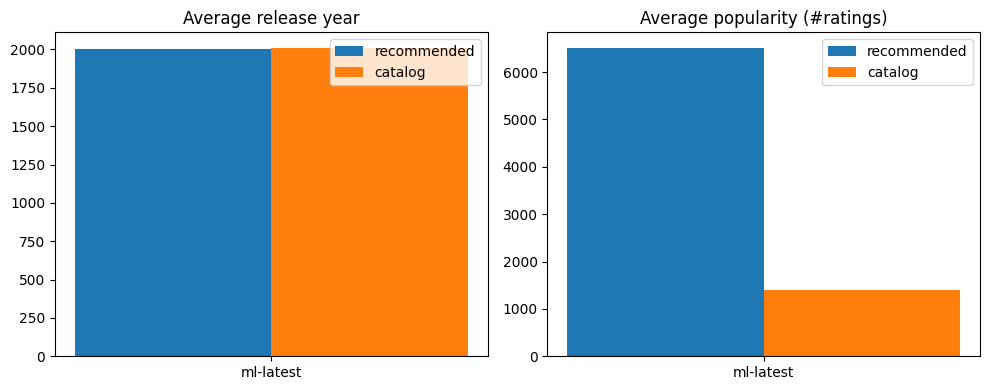

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

x = np.arange(len(bias_df))
width = 0.35
axes[0].bar(x - width / 2, bias_df["rec_avg_year"], width, label="recommended")
axes[0].bar(x + width / 2, bias_df["catalog_avg_year"], width, label="catalog")
axes[0].set_xticks(x)
axes[0].set_xticklabels(bias_df["dataset"])
axes[0].set_title("Average release year")
axes[0].legend()

axes[1].bar(x - width / 2, bias_df["rec_avg_popularity"], width, label="recommended")
axes[1].bar(x + width / 2, bias_df["catalog_avg_popularity"], width, label="catalog")
axes[1].set_xticks(x)
axes[1].set_xticklabels(bias_df["dataset"])
axes[1].set_title("Average popularity (#ratings)")
axes[1].legend()

plt.tight_layout()
plt.show()


In [ ]:
# Filter pipeline audit (uses the same classes as production loader)
from plugins.utils.ml_data_loader import (
    RatingLowFilter,
    MovieFilterByYear,
    RatingFilterOld,
    RatingsPerYearFilter,
    RatingUserFilter,
    RatedMovieFilter,
    LinkFilter,
)

base = ROOT / "server" / "static" / "datasets" / "ml-latest"
ratings_raw = pd.read_csv(base / "ratings.csv")
movies_raw = pd.read_csv(base / "movies.csv")
links_raw = pd.read_csv(base / "links.csv").set_index("movieId")

class LoaderState:
    pass

loader_state = LoaderState()
loader_state.ratings_df = ratings_raw.copy()
loader_state.movies_df = movies_raw.copy()
loader_state.links_df = links_raw.copy()

rows = []

def log_step(step_name: str):
    rows.append({
        "step": step_name,
        "ratings_rows": int(len(loader_state.ratings_df)),
        "rated_movies": int(loader_state.ratings_df.movieId.nunique()),
        "users": int(loader_state.ratings_df.userId.nunique()),
        "movies_df": int(loader_state.movies_df.movieId.nunique()),
        "links_df": int(len(loader_state.links_df)),
    })

log_step("start")
pipeline = [
    ("RatingLowFilter(4.0)", RatingLowFilter(4.0)),
    ("MovieFilterByYear(1990)", MovieFilterByYear(1990)),
    ("RatingFilterOld(2010)", RatingFilterOld(2010)),
    ("RatingsPerYearFilter(50.0)", RatingsPerYearFilter(50.0)),
    ("RatingUserFilter(100)", RatingUserFilter(100)),
    ("RatedMovieFilter()", RatedMovieFilter()),
    ("LinkFilter()", LinkFilter()),
]

for step_name, filt in pipeline:
    filt(loader_state)
    log_step(step_name)

audit_df = pd.DataFrame(rows)
audit_df


In [ ]:
# Sensitivity sweep: lower both strict filters (RatingsPerYear + RatingUser)
from plugins.utils.ml_data_loader import (
    RatingLowFilter,
    MovieFilterByYear,
    RatingFilterOld,
    RatingsPerYearFilter,
    RatingUserFilter,
    RatedMovieFilter,
    LinkFilter,
)

base = ROOT / "server" / "static" / "datasets" / "ml-latest"
ratings_raw = pd.read_csv(base / "ratings.csv")
movies_raw = pd.read_csv(base / "movies.csv")
links_raw = pd.read_csv(base / "links.csv").set_index("movieId")

class LoaderState:
    pass


def run_pipeline(rpy_threshold: float, user_min: int):
    s = LoaderState()
    s.ratings_df = ratings_raw.copy()
    s.movies_df = movies_raw.copy()
    s.links_df = links_raw.copy()

    pipeline = [
        RatingLowFilter(4.0),
        MovieFilterByYear(1990),
        RatingFilterOld(2010),
        RatingsPerYearFilter(float(rpy_threshold)),
        RatingUserFilter(int(user_min)),
        RatedMovieFilter(),
        LinkFilter(),
    ]
    for f in pipeline:
        f(s)

    return {
        "rpy": float(rpy_threshold),
        "min_user_ratings": int(user_min),
        "rated_movies": int(s.ratings_df.movieId.nunique()),
        "ratings_rows": int(len(s.ratings_df)),
        "users": int(s.ratings_df.userId.nunique()),
    }


rpy_candidates = [50, 40, 30, 20, 15, 10]
user_candidates = [100, 80, 60, 40, 30, 20, 10]
rows = []
for rpy in rpy_candidates:
    for umin in user_candidates:
        rows.append(run_pipeline(rpy, umin))

sweep_df = pd.DataFrame(rows).sort_values(["rpy", "min_user_ratings"], ascending=[False, False])
sweep_df


In [ ]:
# Optional visualization: heatmap of final candidate movie count
pivot_movies = sweep_df.pivot(index="rpy", columns="min_user_ratings", values="rated_movies")

plt.figure(figsize=(9, 5))
plt.imshow(pivot_movies.values, aspect="auto")
plt.colorbar(label="Final candidate movies")
plt.xticks(range(len(pivot_movies.columns)), pivot_movies.columns)
plt.yticks(range(len(pivot_movies.index)), pivot_movies.index)
plt.xlabel("RatingUserFilter(min_ratings_per_user)")
plt.ylabel("RatingsPerYearFilter(min_ratings_per_year)")
plt.title("Candidate pool size sensitivity")
plt.tight_layout()
plt.show()

pivot_movies
